<class 'pandas.DataFrame'>
RangeIndex: 1655 entries, 0 to 1654
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1655 non-null   int64  
 1   name                 1655 non-null   str    
 2   hazardous            1655 non-null   bool   
 3   absolute_magnitude   1655 non-null   float64
 4   diameter_min_m       1655 non-null   float64
 5   diameter_max_m       1655 non-null   float64
 6   diameter_avg_m       1655 non-null   float64
 7   size_category        1655 non-null   str    
 8   close_approach_date  1655 non-null   str    
 9   year                 1655 non-null   int64  
 10  month                1655 non-null   int64  
 11  day                  1655 non-null   int64  
 12  velocity_kmh         1655 non-null   float64
 13  velocity_kps         1655 non-null   float64
 14  miss_distance_km     1655 non-null   float64
 15  miss_distance_ld     1655 non-null   float64
 16 

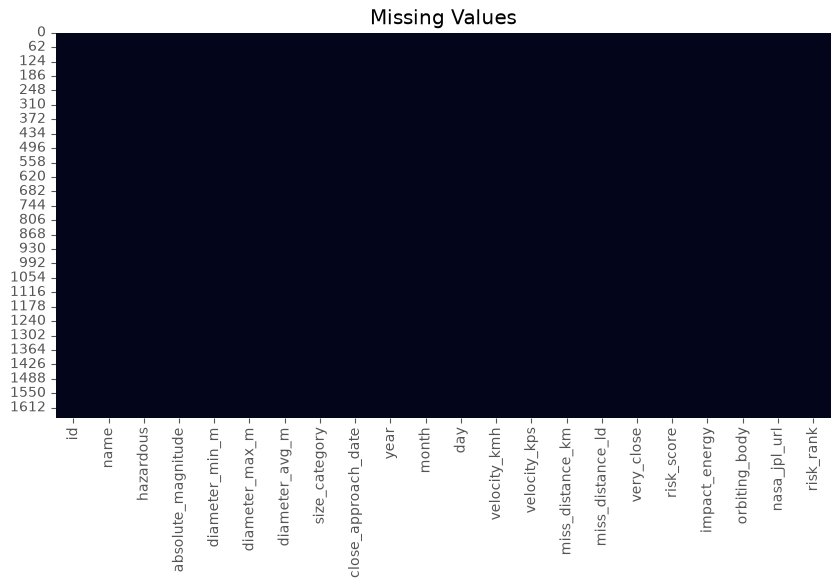

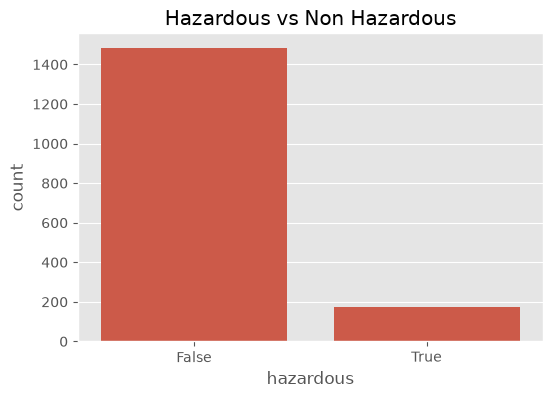

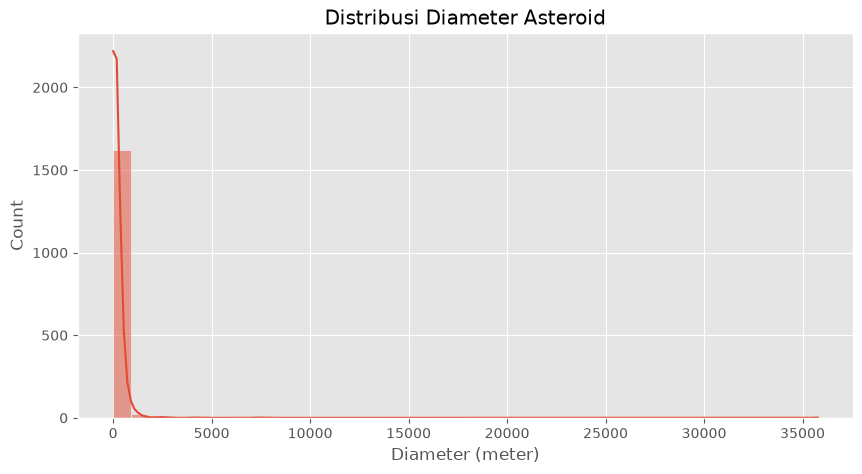

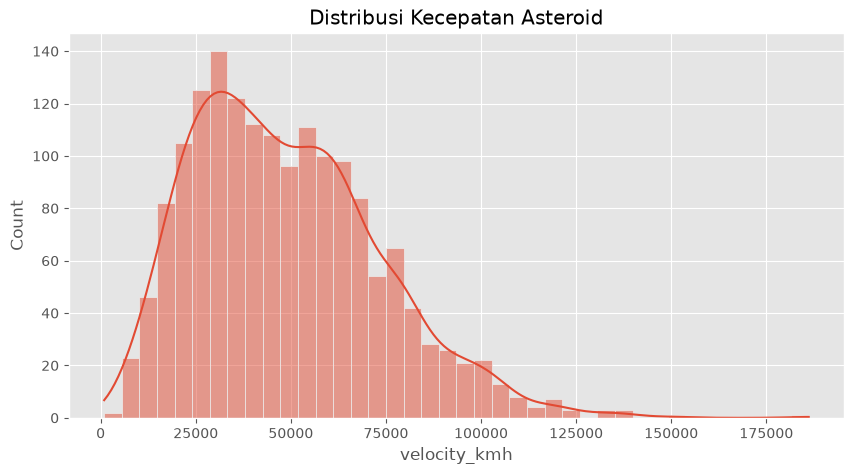

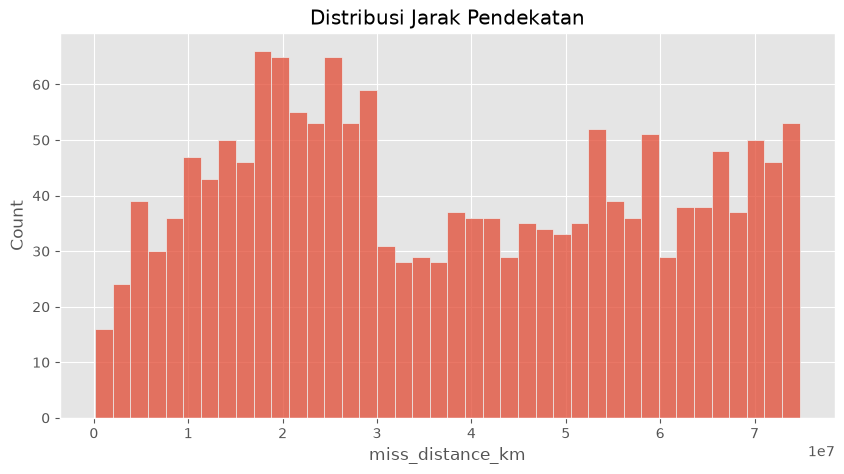

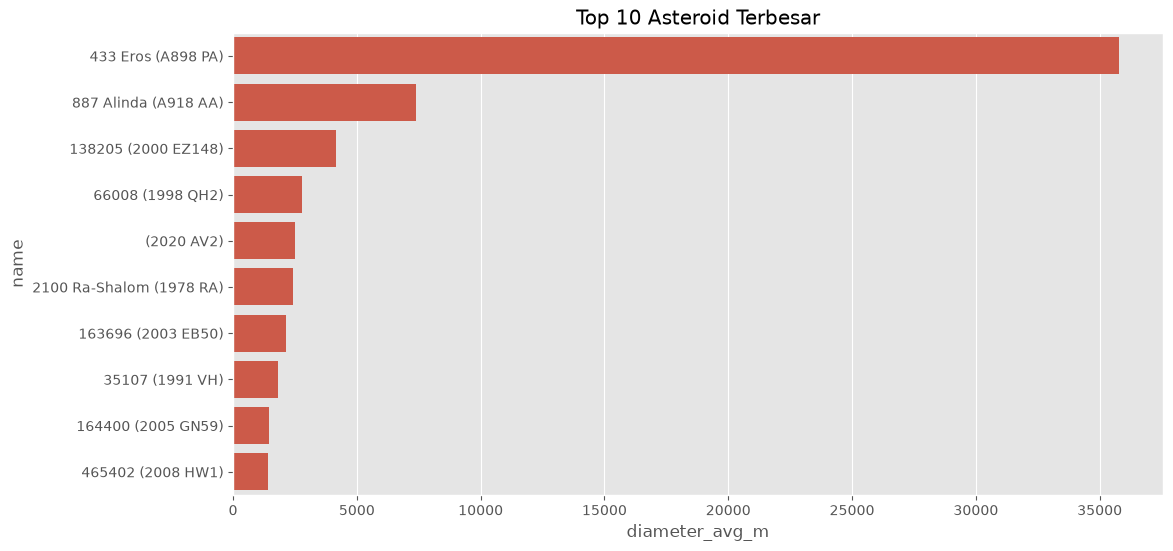

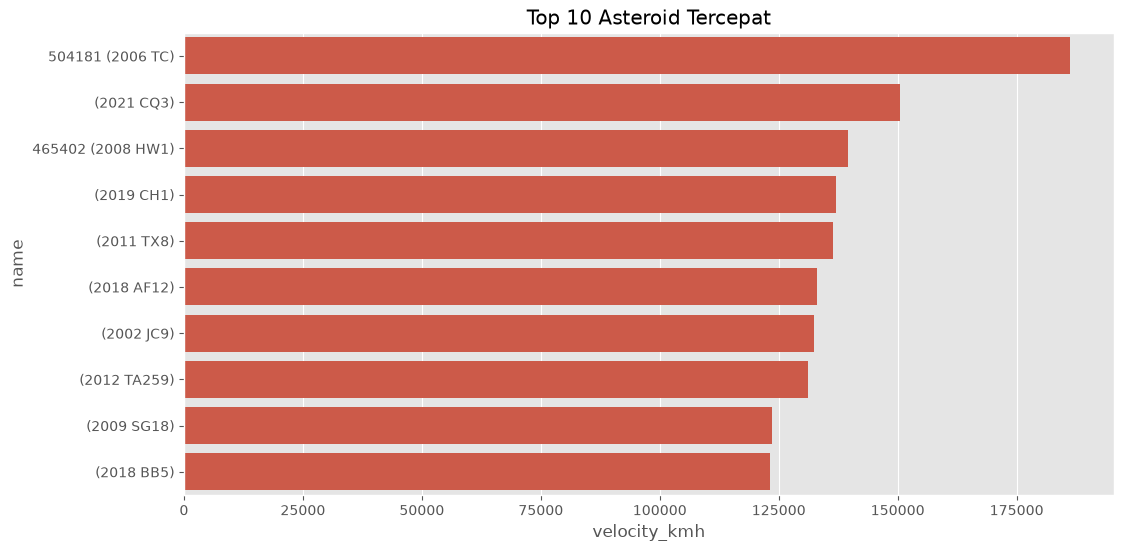

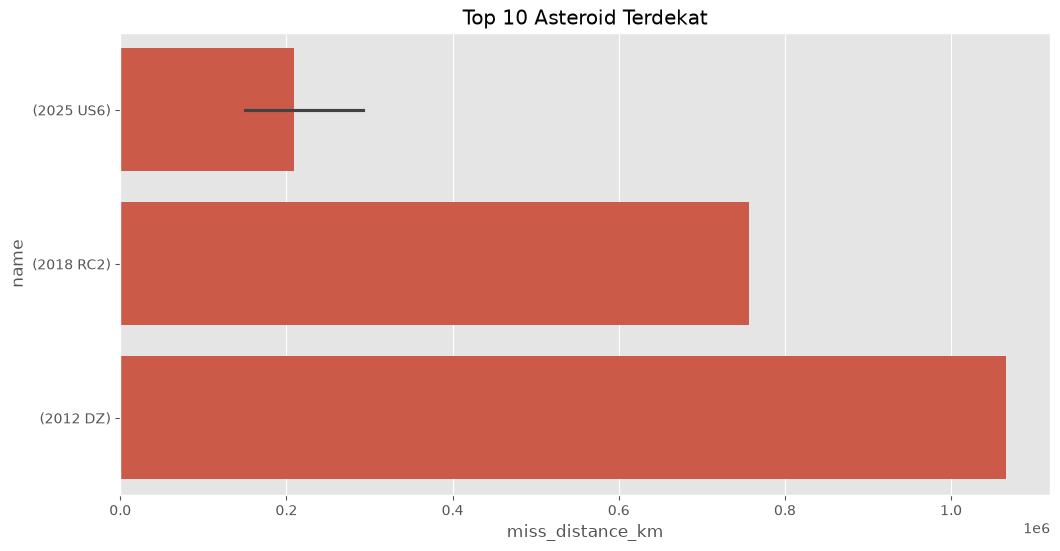

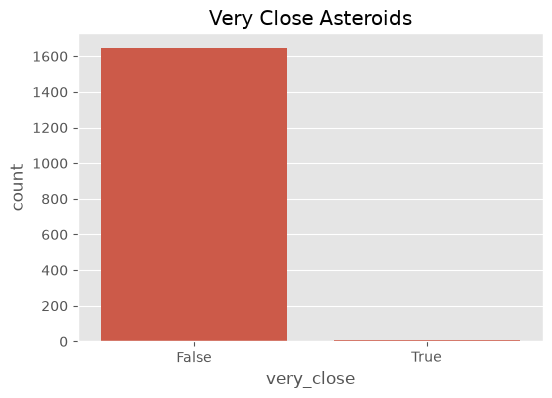

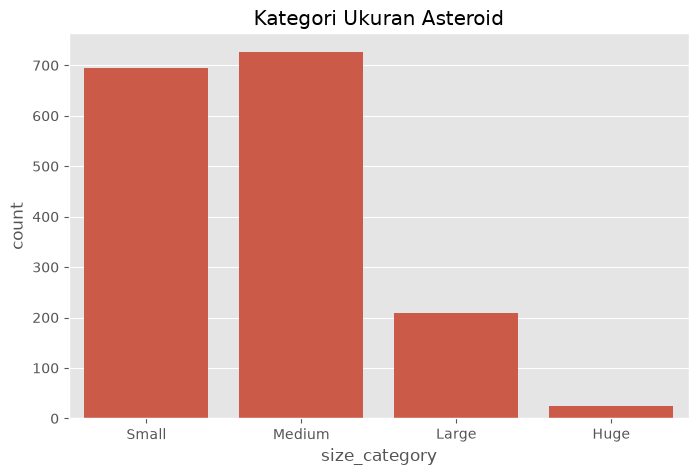

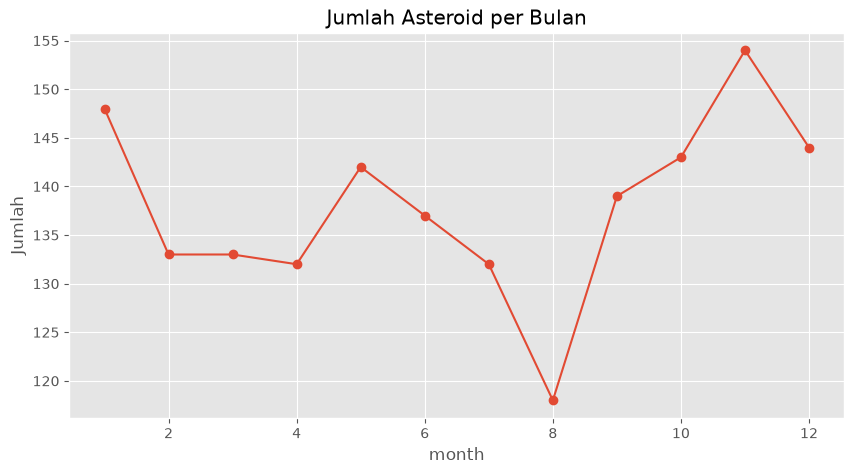

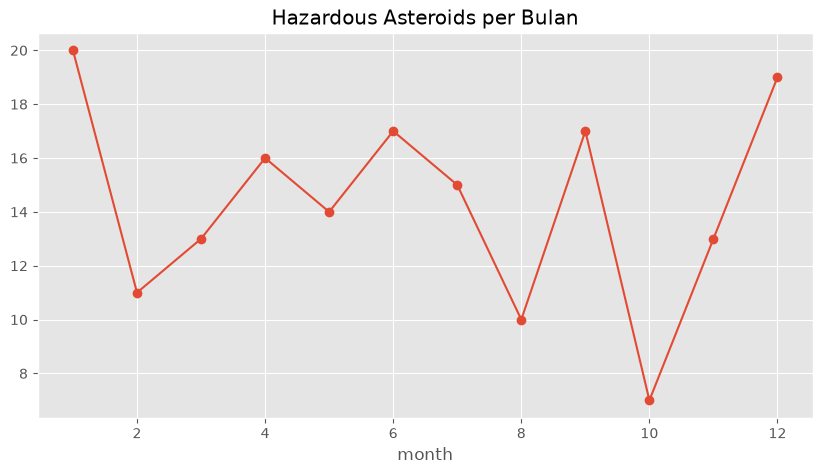

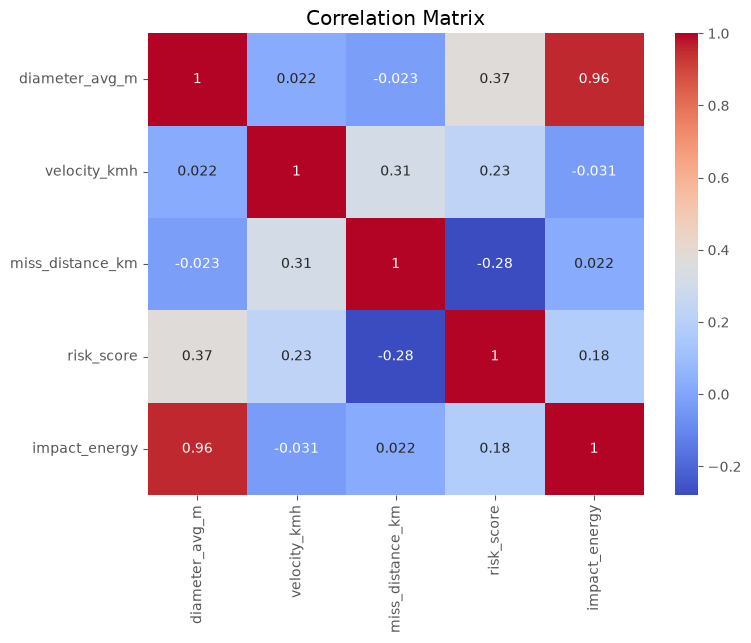

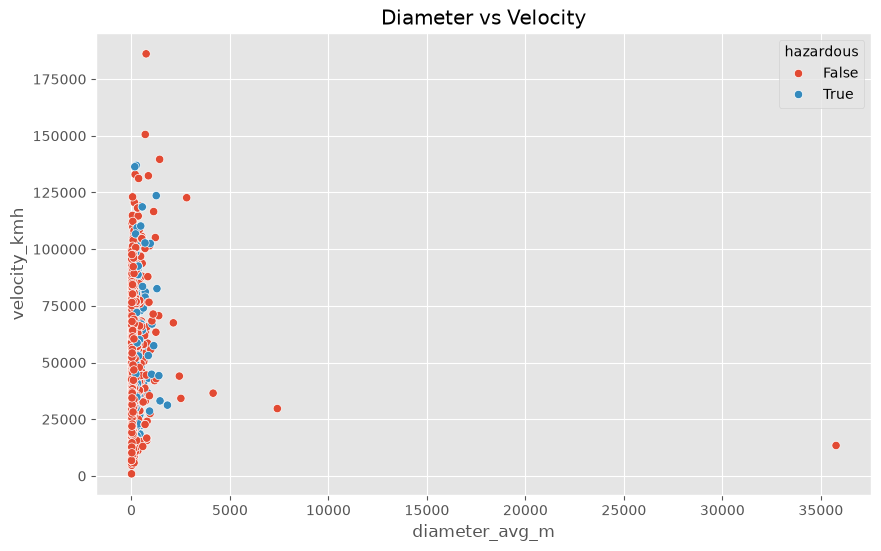

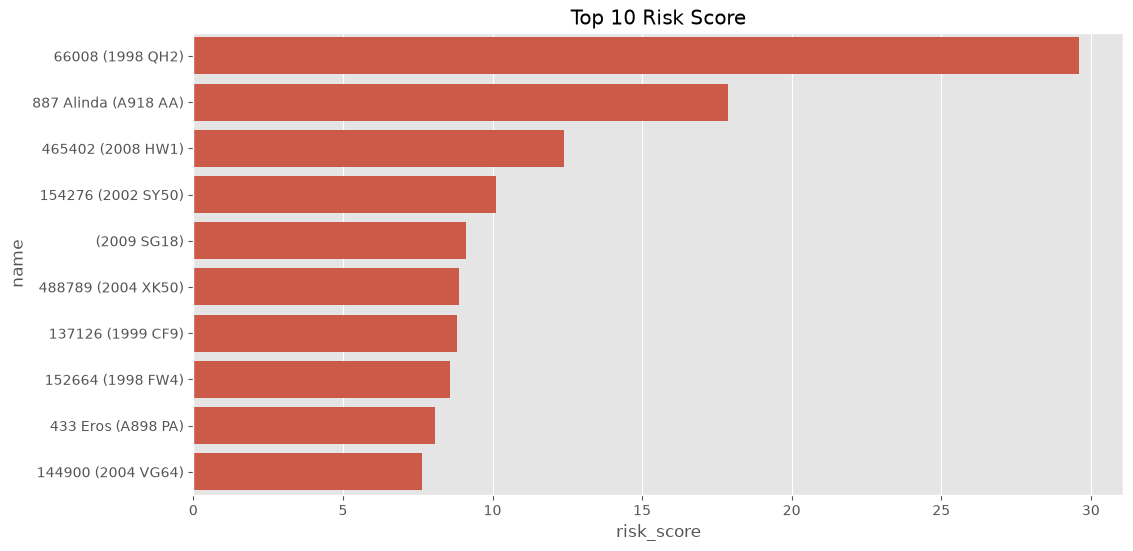

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

df = pd.read_csv("../../data/asteroids_2025.csv")

df.head()

df.shape
df.info()
df.describe()
df.isnull().sum()

print("Jumlah Asteroid:", len(df))
print("Hazardous:", df["hazardous"].sum())
print("Non Hazardous:", (~df["hazardous"]).sum())
print(
    "Diameter Terbesar:",
    round(
        df["diameter_max_m"].max(),
        2
    ),
    "meter"
)

print(
    "Kecepatan Maksimum:",
    round(
        df["velocity_kmh"].max(),
        2
    ),
    "km/jam"
)

print(
    "Jarak Terdekat:",
    round(
        df["miss_distance_km"].min(),
        2
    ),
    "km"
)

# Missing Values
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")
plt.show()

df.duplicated().sum()

# Hazardous vs Non Hazardous
df["hazardous"].value_counts()
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="hazardous"
)

plt.title("Hazardous vs Non Hazardous")
plt.show()

# Distribusi Diameter Asteroid
plt.figure(figsize=(10,5))

sns.histplot(
    df["diameter_avg_m"],
    bins=40,
    kde=True
)

plt.title("Distribusi Diameter Asteroid")
plt.xlabel("Diameter (meter)")
plt.show()

# Distribusi Kecepatan Asteroid
plt.figure(figsize=(10,5))

sns.histplot(
    df["velocity_kmh"],
    bins=40,
    kde=True
)

plt.title("Distribusi Kecepatan Asteroid")
plt.show()

# Distribusi Jarak Pendekatan
plt.figure(figsize=(10,5))

sns.histplot(
    df["miss_distance_km"],
    bins=40
)

plt.title("Distribusi Jarak Pendekatan")
plt.show()

# Top 10 Asteroid Terbesar
top_biggest = (
    df
    .nlargest(
        10,
        "diameter_avg_m"
    )
)

top_biggest[
    [
        "name",
        "diameter_avg_m"
    ]
]

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_biggest,
    x="diameter_avg_m",
    y="name"
)

plt.title("Top 10 Asteroid Terbesar")
plt.show()

# Top 10 Asteroid Tercepat
top_fastest = (
    df
    .nlargest(
        10,
        "velocity_kmh"
    )
)

top_fastest[
    [
        "name",
        "velocity_kmh"
    ]
]

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_fastest,
    x="velocity_kmh",
    y="name"
)

plt.title("Top 10 Asteroid Tercepat")
plt.show()

# Top 10 Asteroid Terdekat
top_closest = (
    df
    .nsmallest(
        10,
        "miss_distance_km"
    )
)

top_closest[
    [
        "name",
        "miss_distance_km"
    ]
]

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_closest,
    x="miss_distance_km",
    y="name"
)

plt.title("Top 10 Asteroid Terdekat")
plt.show()

# Very Close Asteroids
df["very_close"].value_counts()

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="very_close"
)

plt.title("Very Close Asteroids")
plt.show()

# Kategori Ukuran Asteroid
df["size_category"].value_counts()

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="size_category",
    order=[
        "Small",
        "Medium",
        "Large",
        "Huge"
    ]
)

plt.title("Kategori Ukuran Asteroid")
plt.show()

# Jumlah Asteroid per Bulan
monthly = (
    df
    .groupby("month")
    .size()
)

plt.figure(figsize=(10,5))

monthly.plot(
    marker="o"
)

plt.title("Jumlah Asteroid per Bulan")
plt.ylabel("Jumlah")
plt.show()

# Hazardous Asteroids per Bulan
hazard_month = (
    df[df["hazardous"] == True]
    .groupby("month")
    .size()
)

plt.figure(figsize=(10,5))

hazard_month.plot(
    marker="o"
)

plt.title("Hazardous Asteroids per Bulan")
plt.show()

# Correlation Matrix
numeric_cols = [
    "diameter_avg_m",
    "velocity_kmh",
    "miss_distance_km",
    "risk_score",
    "impact_energy"
]

corr = df[numeric_cols].corr()

corr

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

# Diameter vs Velocity
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="diameter_avg_m",
    y="velocity_kmh",
    hue="hazardous"
)

plt.title("Diameter vs Velocity")
plt.show()

# Top Risky Asteroids
top_risk = (
    df
    .nlargest(
        10,
        "risk_score"
    )
)

top_risk[
    [
        "name",
        "risk_score"
    ]
]

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_risk,
    x="risk_score",
    y="name"
)

plt.title("Top 10 Risk Score")
plt.show()